In [162]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits
    #standard import modules

In [163]:
hdul = fits.open("Planet_Lightcurve.fits")
data = hdul[1].data

    #open/import "planet_lightcurve.fits"

ColDefs(
    name = 'time [days]'; format = 'D'
    name = 'flux'; format = 'D'
)


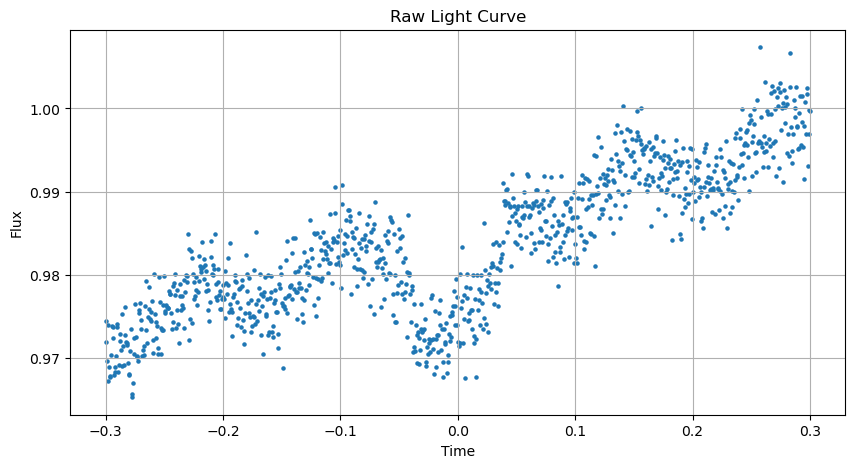

In [164]:
data = hdul[1].data

print(data.columns)
    #Use this to find appropiate names per column name
time = data['time [days]']
flux = data['flux']


plt.figure(figsize=(10,5))
plt.scatter(time, flux, s=5)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Raw Light Curve")
plt.grid()
plt.savefig("raw_lightcurve.pdf")
plt.show()
    #plot the data

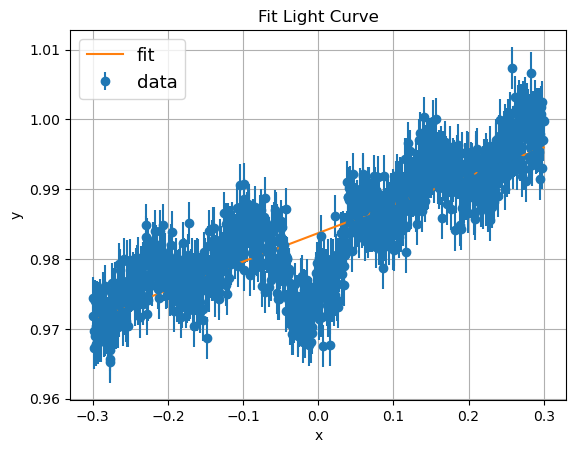

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits

def model_line(x, m, b):
    y_model = m*x + b
    return y_model
    
x = np.array(data['time [days]'])  
y_new = np.array(data['flux'])  
y_err = np.full(len(y_new), 0.003)  

#perform the fit.
#curve_fit returns too variables
#the first is an array with the best fit parameters. 

params, params_cov = curve_fit(model_line, x, y_new, sigma = y_err, p0 = [1,0])

m_fit = params [0]
b_fit = params [1]

y_fit = model_line(x, m_fit, b_fit)

plt.errorbar(x, y_new, yerr = y_err, fmt='o', label='data')
plt.plot(x, y_fit, label="fit")
plt.legend(fontsize=13)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fit Light Curve")
plt.grid()
plt.savefig("Fit_lightcurve.pdf")
plt.show()

c0 = 0.9837313240968819 +/- 9.502844982019333e-05
slope = 0.03928543151157837 +/- 0.0005566135335305035
A = 0.002724874292295907 +/- 0.00013386973690184586
frequency = 8.041686573263954 +/- 0.0473893765472997
phase = -0.21312851671072397 +/- 0.04998756214333893


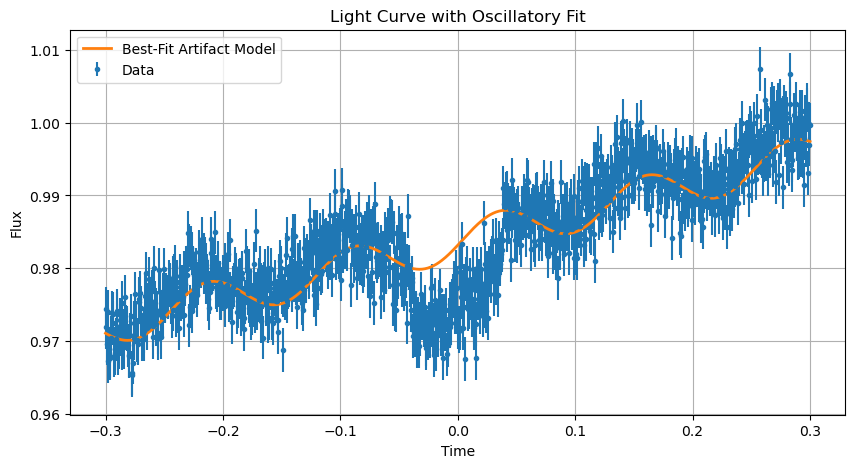

In [166]:
#get rid of the unwanted objects

def artifact_model(t, c0, slope, A, freq, phi):
    return c0 + slope*t + A*np.sin(2*np.pi*freq*t + phi)

params, cov = curve_fit(artifact_model, x, y_new, sigma=y_err, absolute_sigma=True, p0=[1.0, 0.0, 0.01, 8.0, 0.0])

c0_fit, slope_fit, A_fit, freq_fit, phi_fit = params

param_err = np.sqrt(np.diag(cov))

#acknowledge possible uncertainties

print("c0 =", c0_fit, "+/-", param_err[0])
print("slope =", slope_fit, "+/-", param_err[1])
print("A =", A_fit, "+/-", param_err[2])
print("frequency =", freq_fit, "+/-", param_err[3])
print("phase =", phi_fit, "+/-", param_err[4])

y_fit = artifact_model(x, *params)
plt.figure(figsize=(10,5))
plt.errorbar(x, y_new, yerr=y_err, fmt='.', label='Data')
plt.plot(x, y_fit, lw=2, label='Best-Fit Artifact Model')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Light Curve with Oscillatory Fit")
plt.legend()
plt.grid()
plt.savefig("artifact_fit.pdf")
plt.show()


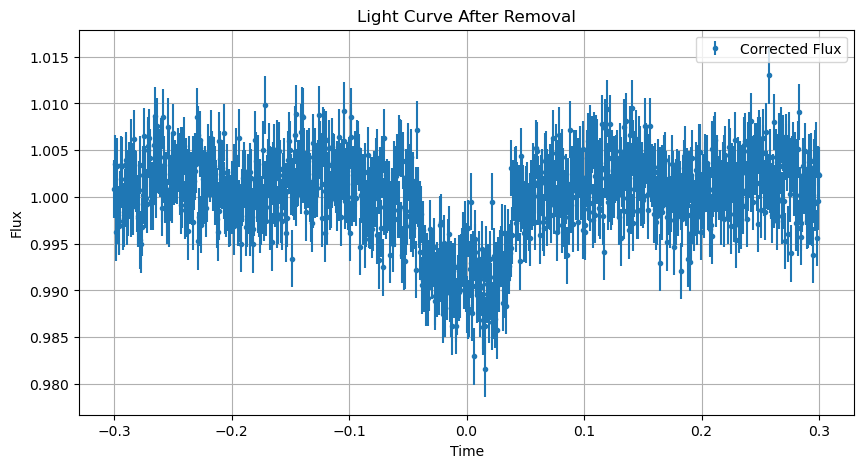

In [167]:
#perform the corrected plot, dividing out any artifiacts or oscillatory objects

flux_corrected = y_new / y_fit

plt.figure(figsize=(10,5))
plt.errorbar(x, flux_corrected, yerr=y_err/y_fit,
             fmt='.', label='Corrected Flux')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Light Curve After Removal")
plt.legend()
plt.grid()
plt.savefig("lightcurve_after_removal.pdf")
plt.show()

mask = y_new > 0.985

params, cov = curve_fit(artifact_model, x[mask], y_new[mask], sigma=y_err[mask], absolute_sigma=True,p0=[1.0, 0.0, 0.01, 8.0, 0.0])